In [103]:
# reload module automatically when edited
%load_ext autoreload
%autoreload 2
from IAR_PROJET import *
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import cv2
from IPython.display import Video

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Objectif : Au minimum, reproduire le modèle avec TD-learning seul, et celui avec l’ajout de la
navigation métrique. L’objectif est de produire vos propres versions des figures 3 (vérification du
bon fonctionnement du TD-RL), 4a (comportement du TD-RL dans la tâche de piscine avec un
changement de position de la plateforme), 6 (vérification du bon fonctionnement de la navigation
métrique) et 8a (comportement du système complet dans la tâche de piscine avec un
changement de place de la plateforme)

---
# Environment Class
---

### Initialize and display Environment

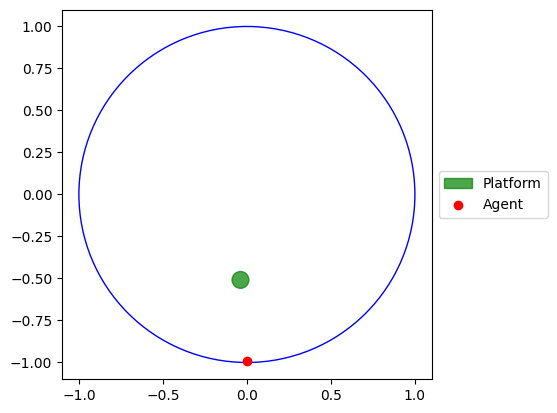

In [2]:
env = Environment()
env.display()

### Reset environment with RMW (platform stays in place)

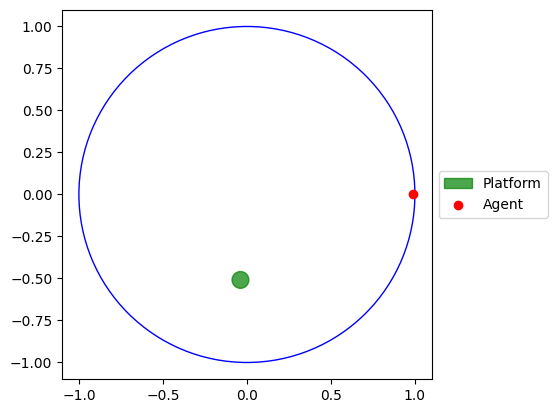

In [3]:
env.reset("RMW")
env.display()

### Reset Environment with DMP (platform is moved randomly)

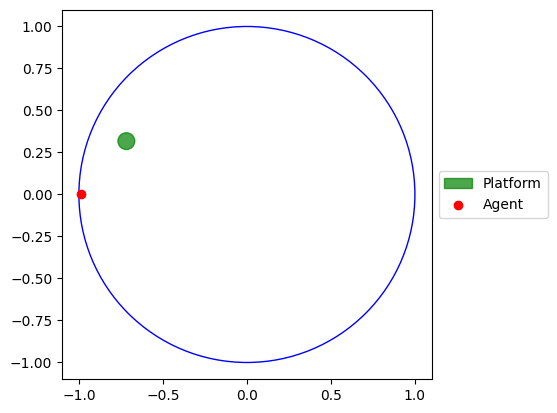

In [4]:
env.reset("DMP")
env.display()

### Step Function

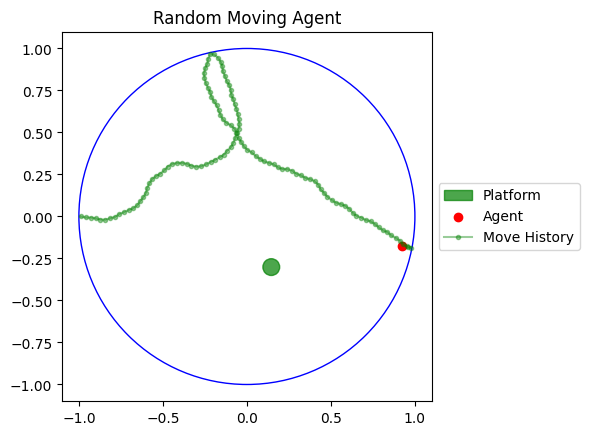

In [5]:
demoenv = DemoEnv()

max_steps = 120
fps = 20
start_pos = None
move_dir = None

demoenv.step_function_demo(max_steps=max_steps, fps=fps,
                                    start_pos=start_pos, move_dir=move_dir,
                                    save_path="animation_random.mp4",
                                    title="Random Moving Agent")
Video("animation_random.mp4", embed=True)

---
# Place Cells
---

(493, 2)


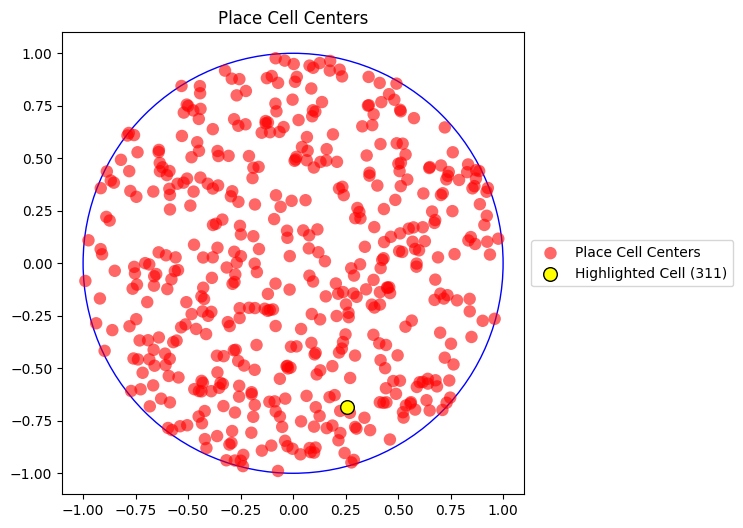

In [6]:
env = Environment()
place_cells = PlaceCells(env, n_cells=493, sigma=0.16)
print(place_cells.centers.shape)
selected_place_cell_id = np.random.randint(0, place_cells.n_cells)
place_cells.display_centers(highlight_id=selected_place_cell_id)

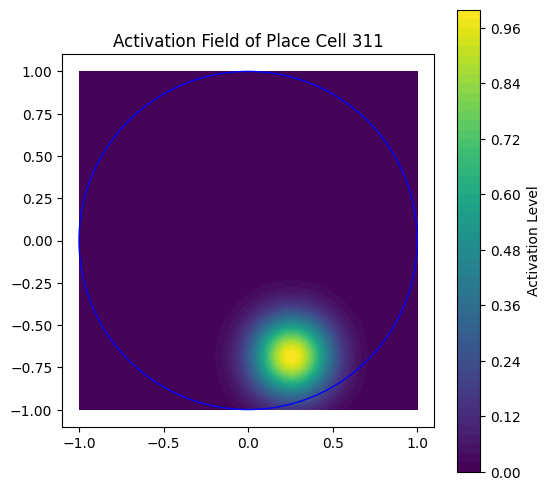

In [7]:
place_cells.display_activation_field(selected_place_cell_id, grid_size=100)

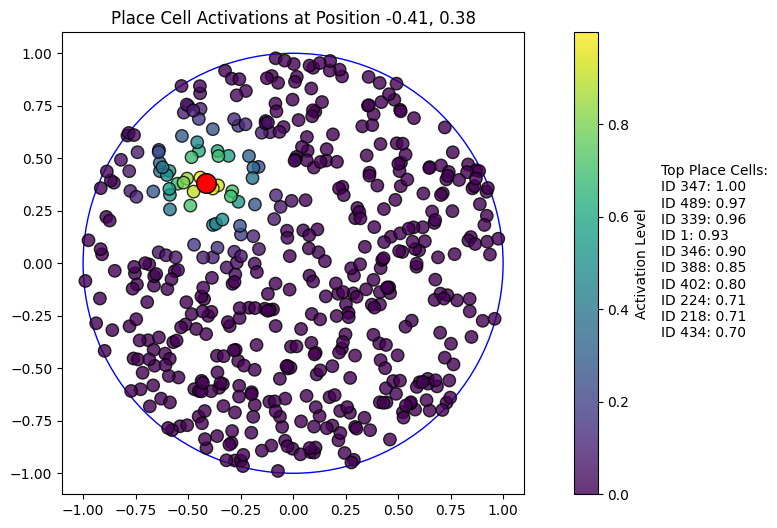

In [8]:
place_cells.display_all_place_activation_by_location()

---
# TD Agent Class
---

Trial 1: 


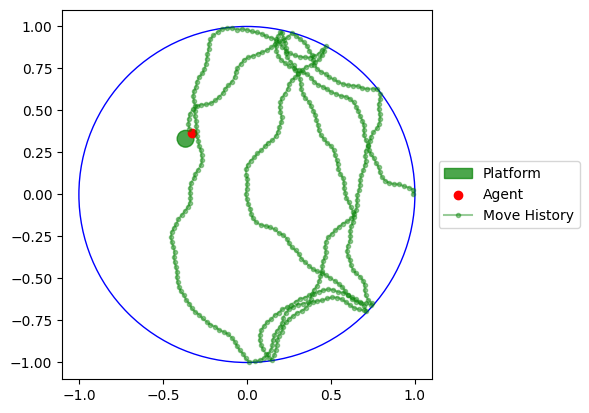

Trial 22: 


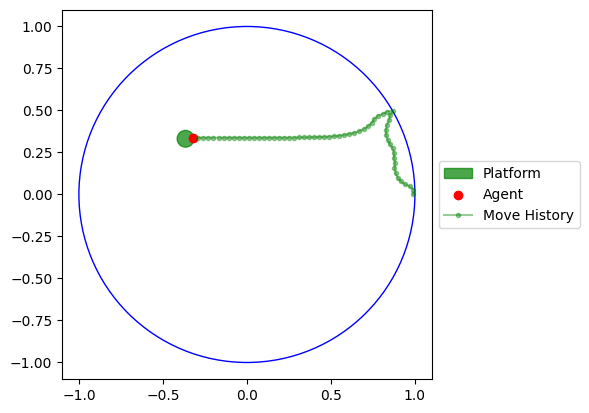

In [265]:
trial_count = 22
env = Environment()
agent = TD_Agent(env)
print(f"Trial 1: ")
#agent.critic.display_value_function()
_ = agent.run_trial("RMW")
env.display()
for _ in range(trial_count - 2):
    _ = agent.run_trial("RMW")
print(f"Trial {trial_count}: ")
#agent.critic.display_value_function()
_ = agent.run_trial("RMW")
env.display()

---
# Figure 3
---

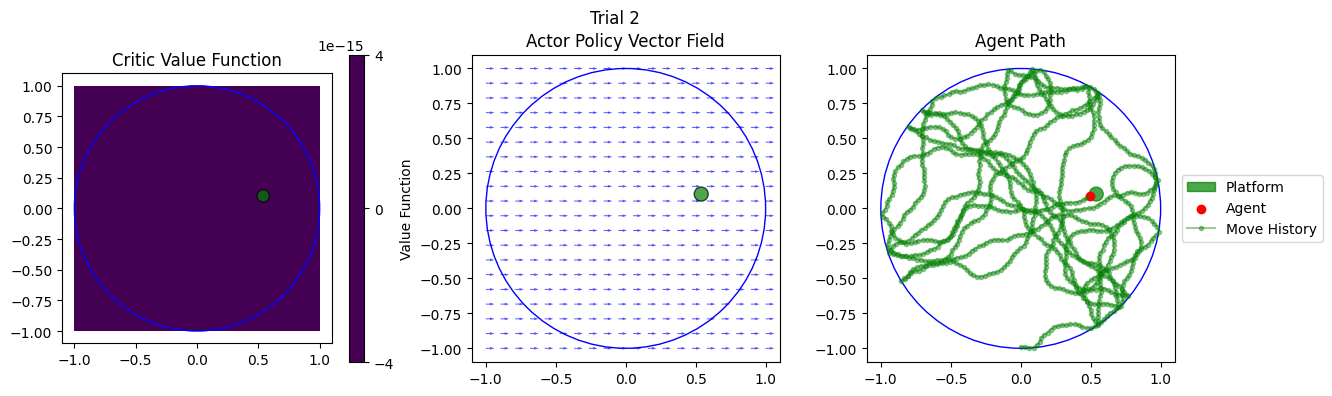

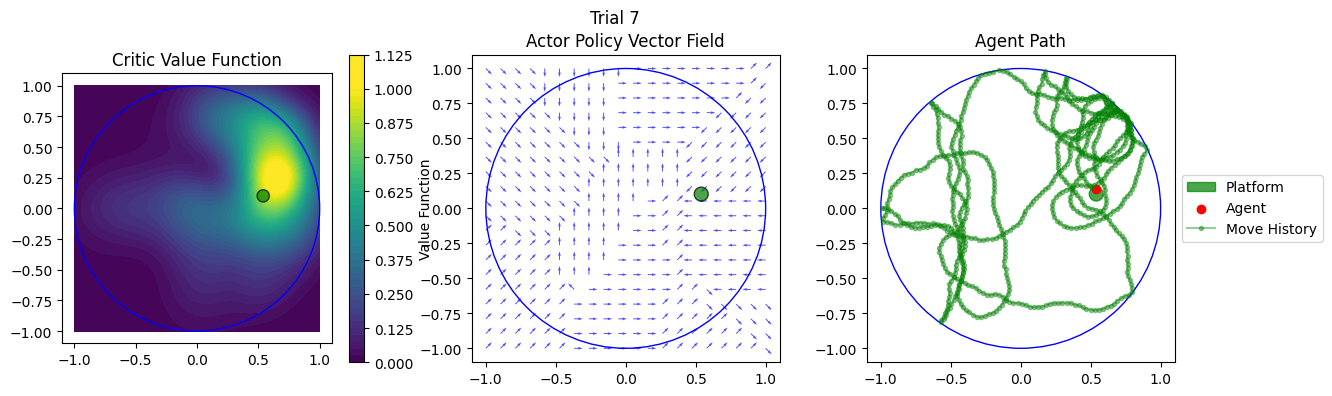

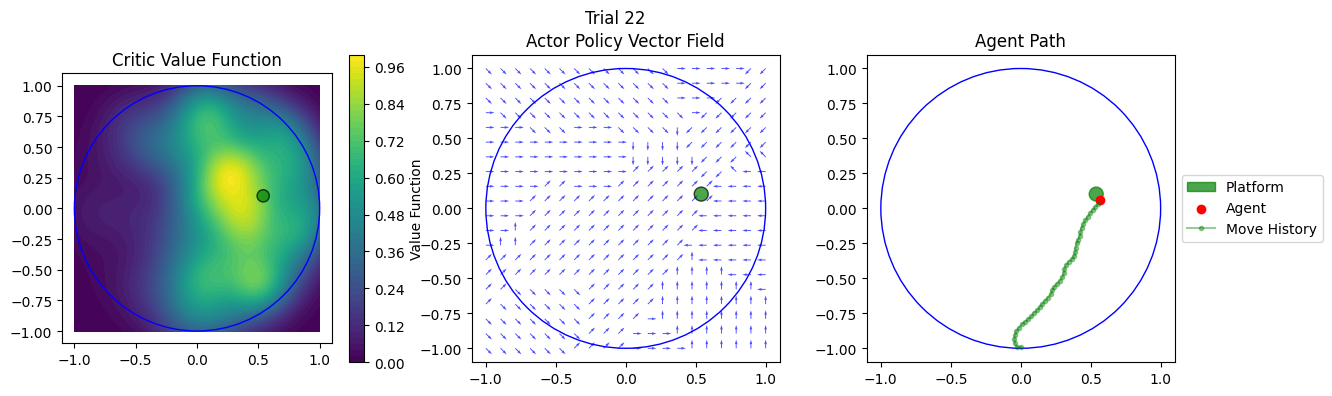

In [21]:
env = Environment()
agent = TD_Agent(env)
trial_mode = "RMW"
selected_trials = [2, 7, 22]

for trial_num in range(1, max(selected_trials) + 1):
    if trial_num in selected_trials:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(f"Trial {trial_num}")
        fig.tight_layout()
        plt.sca(axes[0])
        agent.critic.display_value_function(plt_show=False)
        plt.sca(axes[1])
        agent.actor.display_policy(plt_show=False)
        agent.run_trial(trial_mode)
        plt.sca(axes[2])
        env.display(plt_show=False, title="Agent Path")
        plt.show()
    else:
        temp = agent.run_trial(trial_mode)

---
# Figure 4
### 1000 Simulations (Like in the paper)
---

## Figure 4.a

Experiment Time: 805.53 seconds


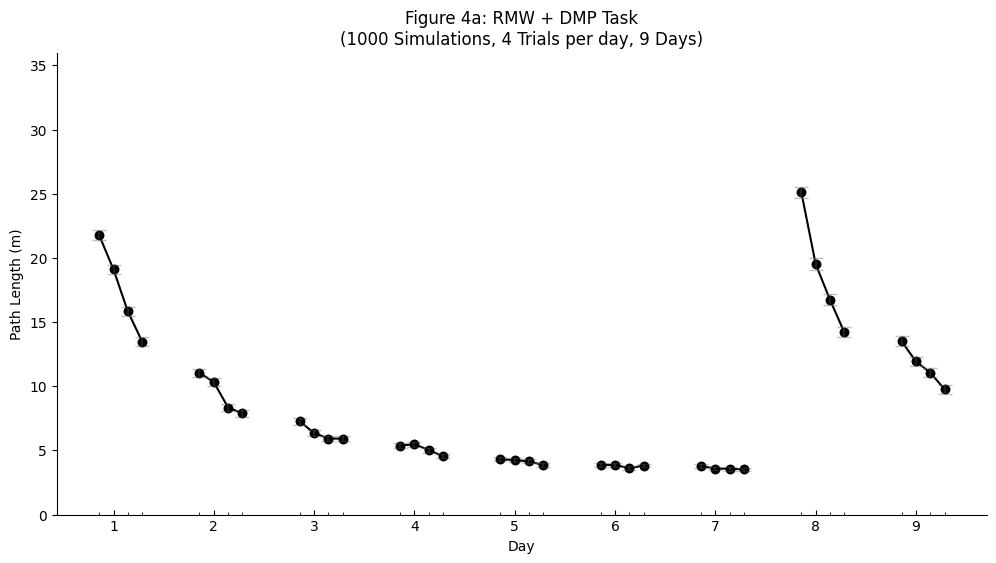

In [24]:
env_4a = Environment()
agent_4a = TD_Agent(env_4a)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 1000

start_time = time.time()
results_4a = agent_4a.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent_4a.display_figure4(results_4a, title="Figure 4a: RMW + DMP Task\n(1000 Simulations, 4 Trials per day, 9 Days)")

## Figure 4.b

Experiment Time: 1517.31 seconds


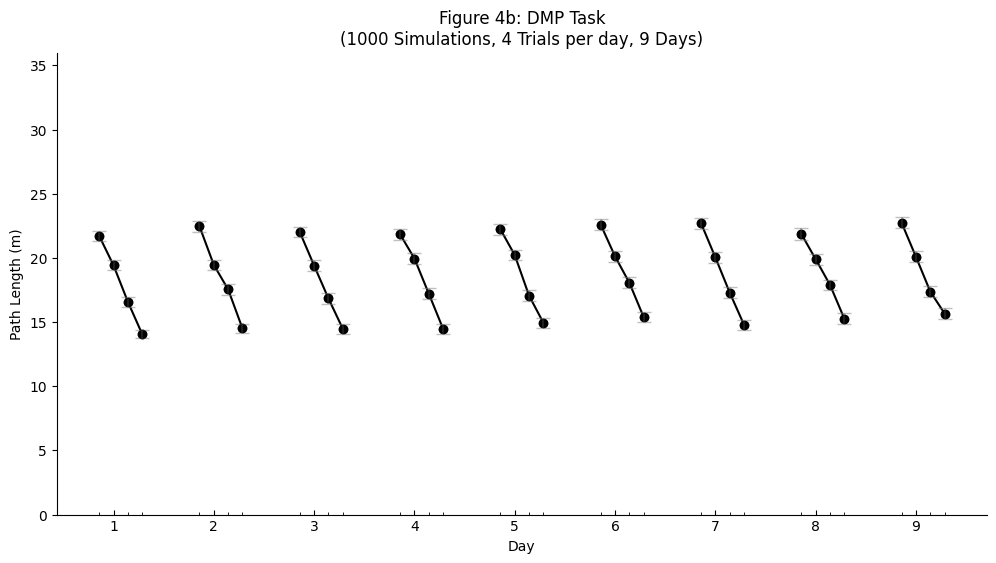

In [25]:
env_4b = Environment()
agent_4b = TD_Agent(env_4b)

trials_by_day = ["DMP"] * 9
trials_per_day = 4
simulation_count = 1000

start_time = time.time()
results_4b = agent_4b.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent_4b.display_figure4(results_4b, title="Figure 4b: DMP Task\n(1000 Simulations, 4 Trials per day, 9 Days)")

---
# Coordinate System
---

Step 1000/10000
Step 2000/10000
Step 3000/10000
Step 4000/10000
Step 5000/10000
Step 6000/10000
Step 7000/10000
Step 8000/10000
Step 9000/10000
Step 10000/10000


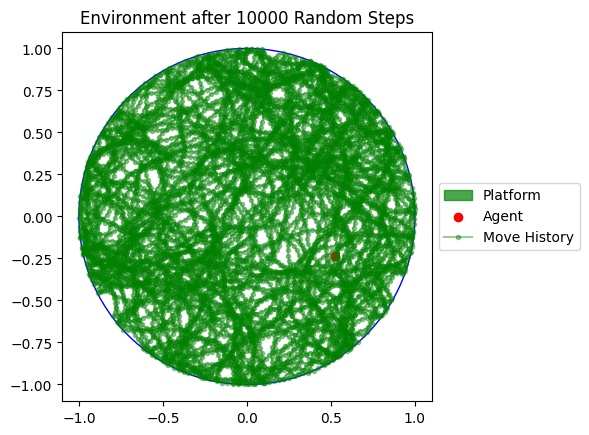

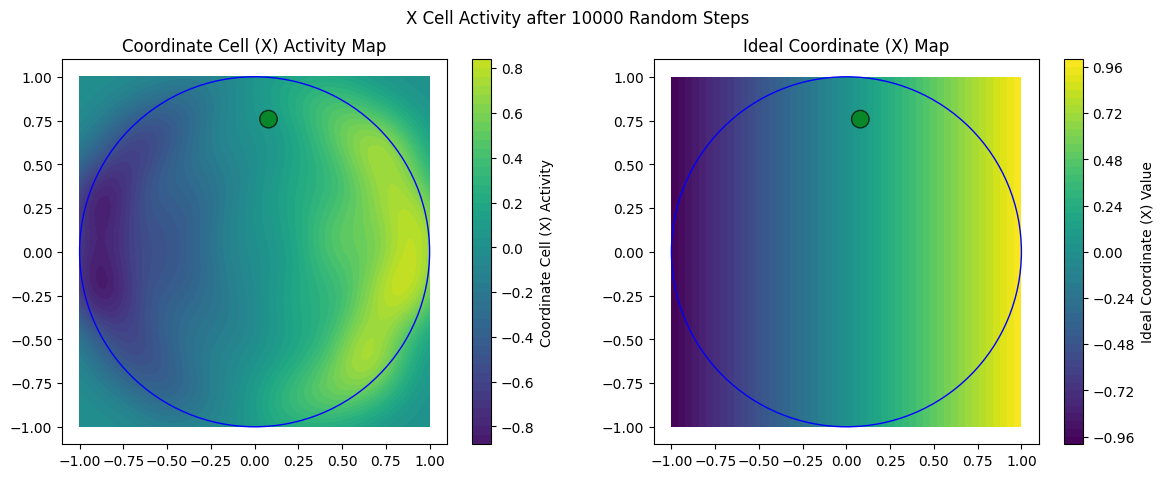

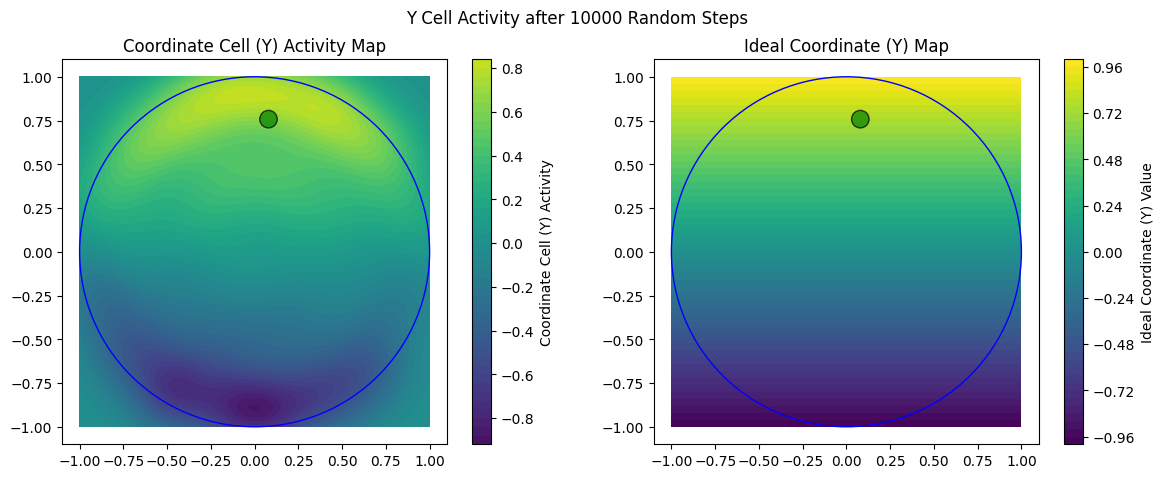

In [119]:
# Randomly move around for a while and see how well the coordinates are estimated
env = Environment(timeout=1000000)
c_agent = Coordinate_TD_Agent(env)
n_steps = 10000
for step in range(n_steps):
    movement_vector = env.random_movement_vector()
    c_activation = c_agent.place_cells.get_activation(env.pos)
    temp_pos = env.pos.copy()
    env.step(movement_vector)
    real_movement_vector = env.pos - temp_pos
    n_activation = c_agent.place_cells.get_activation(env.pos)
    c_agent.coordinates.update(c_activation, n_activation, real_movement_vector)
    # print 10 times during the whole n_steps
    if (step + 1) % (n_steps // 10) == 0:
        print(f"Step {step + 1}/{n_steps}")
# Display final results
env.display(title=f"Environment after {n_steps} Random Steps")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"X Cell Activity after {n_steps} Random Steps")
plt.sca(axes[0])
c_agent.coordinates.display_cell_activity("x", plt_show=False)
plt.sca(axes[1])
c_agent.coordinates.display_ideal_cell_activity("x", plt_show=False)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Y Cell Activity after {n_steps} Random Steps")
plt.sca(axes[0])
c_agent.coordinates.display_cell_activity("y", plt_show=False)
plt.sca(axes[1])
c_agent.coordinates.display_ideal_cell_activity("y", plt_show=False)
plt.show()

---
# Figure 6
---

--- Starting Day 1 (Platform: [0.0282788  0.31252528]) ---
--- Starting Day 2 (Platform: [-0.53564547  0.27339272]) ---
>>> Plotting Day 2, Trial 2


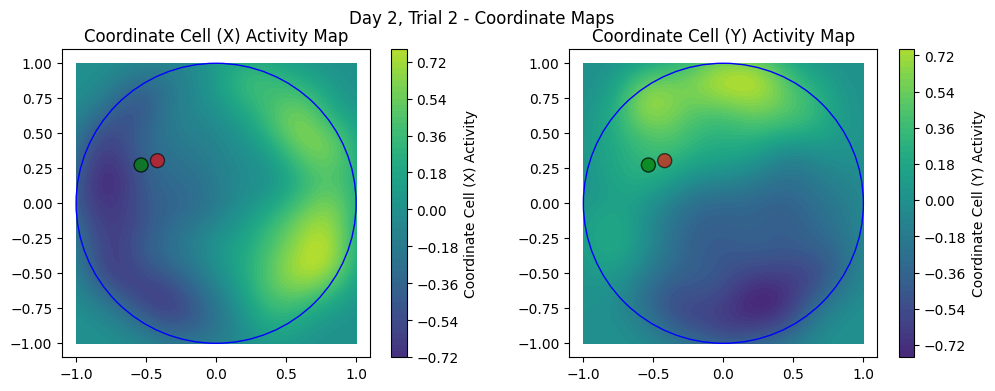

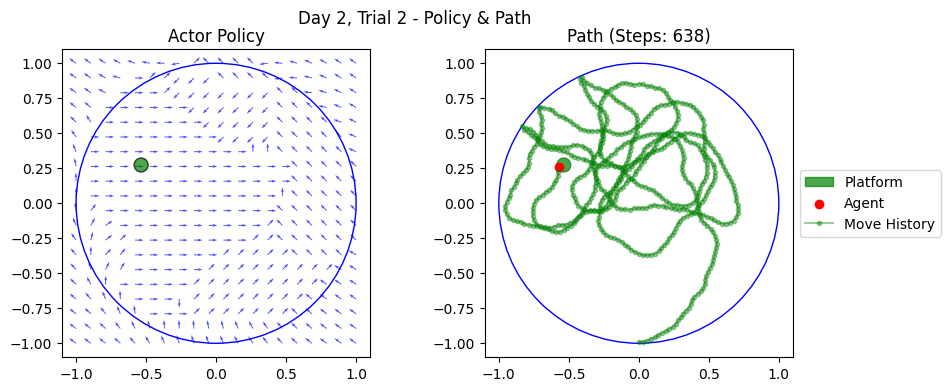

--- Starting Day 3 (Platform: [-0.35521954  0.42781904]) ---
--- Starting Day 4 (Platform: [-0.12145236 -0.4123825 ]) ---
--- Starting Day 5 (Platform: [ 0.45095236 -0.13771975]) ---
--- Starting Day 6 (Platform: [0.2487933  0.02684704]) ---
>>> Plotting Day 6, Trial 2


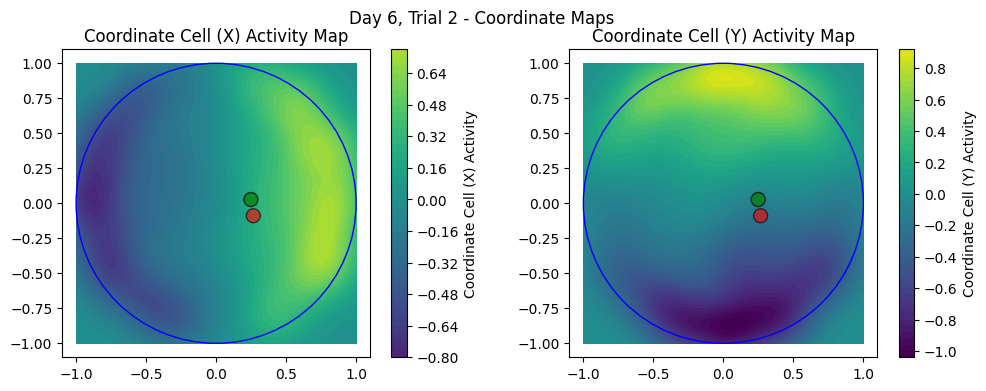

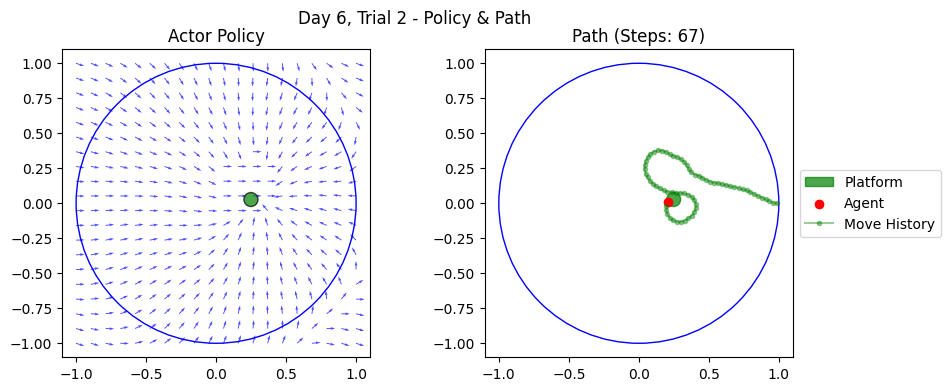

--- Starting Day 7 (Platform: [-0.06217811  0.68184753]) ---
--- Starting Day 8 (Platform: [-0.28408967 -0.09849184]) ---
--- Starting Day 9 (Platform: [ 0.51082233 -0.46631783]) ---


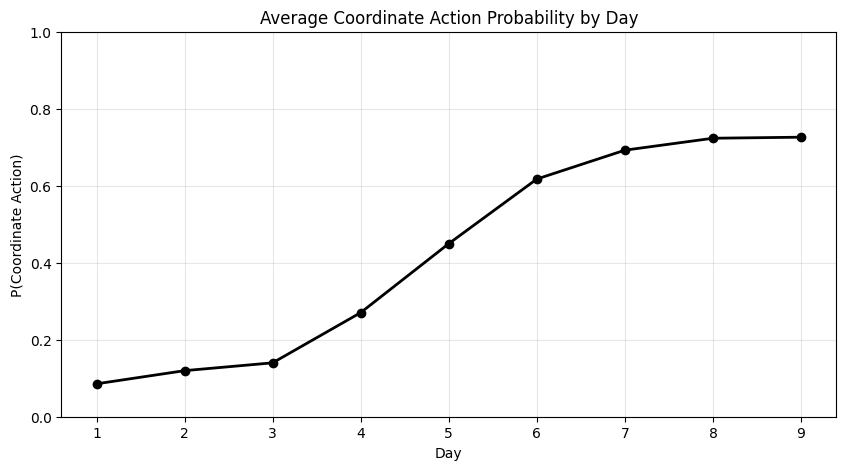

In [268]:
env = Environment()
c_agent = Coordinate_TD_Agent(env)
trials_per_day = 4
total_days = 9 

plot_targets = [(2, 2), (6, 2)] 

p_coordinate_actions = []

for day in range(1, total_days + 1):
    # Start of Day: Move platform if DMP
    # (paper uses DMP in figure 6)
    env.reset("DMP")
    
    print(f"--- Starting Day {day} (Platform: {env.platform_pos}) ---")
    
    for trial in range(1, trials_per_day + 1):
        #print(f"Day {day}, Trial {trial}:")
        if (day, trial) in plot_targets:
            print(f">>> Plotting Day {day}, Trial {trial}")
            
            # Coordinate Cell Activities (X and Y)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f"Day {day}, Trial {trial} - Coordinate Maps")
            plt.sca(axes[0])
            c_agent.coordinates.display_cell_activity("x", plt_show=False, show_perceived_target=True)
            plt.sca(axes[1])
            c_agent.coordinates.display_cell_activity("y", plt_show=False, show_perceived_target=True)
            plt.show()
            
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            fig.suptitle(f"Day {day}, Trial {trial} - Policy & Path")
            
            # Actor Policy
            plt.sca(axes[0])
            c_agent.display_actor_policy(plt_show=False, title="Actor Policy")
            
            step_count, path_len, _, _, p_coord = c_agent.run_trial("RMW")
            
            # Path Plotting
            plt.sca(axes[1])
            env.display(plt_show=False, title=f"Path (Steps: {step_count})")
            plt.show()
            
        else:
            step_count, path_len, _, _, p_coord = c_agent.run_trial("RMW")
        
        p_coordinate_actions.append(p_coord)

p_coordinate_actions = np.array(p_coordinate_actions)
daily_means = p_coordinate_actions.reshape(-1, trials_per_day).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.title(f"Average Coordinate Action Probability by Day")
plt.plot(range(1, total_days + 1), daily_means, marker='o', linewidth=2, color='black')
plt.xlabel("Day")
plt.ylabel("P(Coordinate Action)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

--- Starting Day 1 (Platform: [ 0.55873098 -0.27445397]) ---
--- Starting Day 2 (Platform: [-0.62409951 -0.10261345]) ---
>>> Plotting Day 2, Trial 2


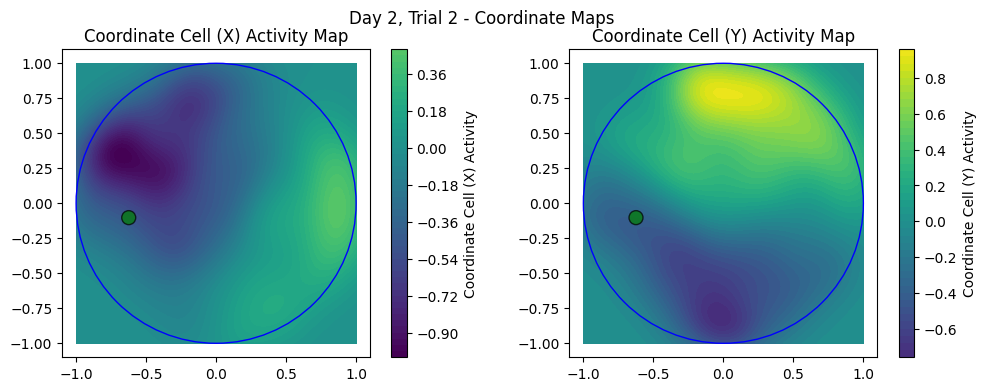

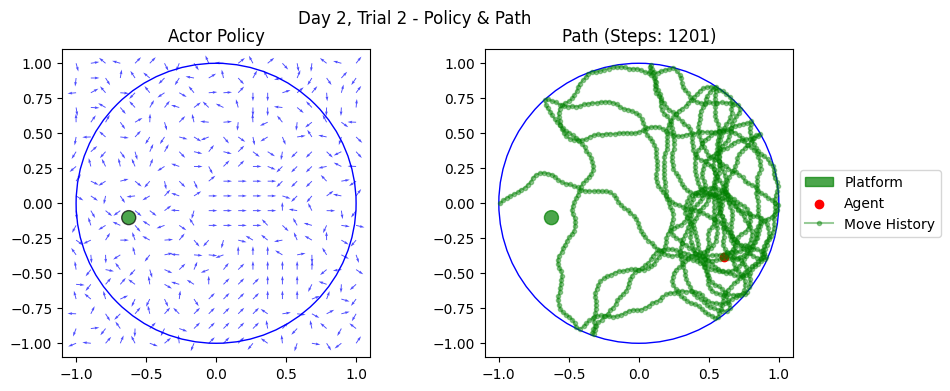

--- Starting Day 3 (Platform: [0.21556264 0.26746331]) ---
--- Starting Day 4 (Platform: [ 0.63990812 -0.05433354]) ---
--- Starting Day 5 (Platform: [ 0.02452096 -0.40264593]) ---
--- Starting Day 6 (Platform: [ 0.20805845 -0.15927022]) ---
>>> Plotting Day 6, Trial 2


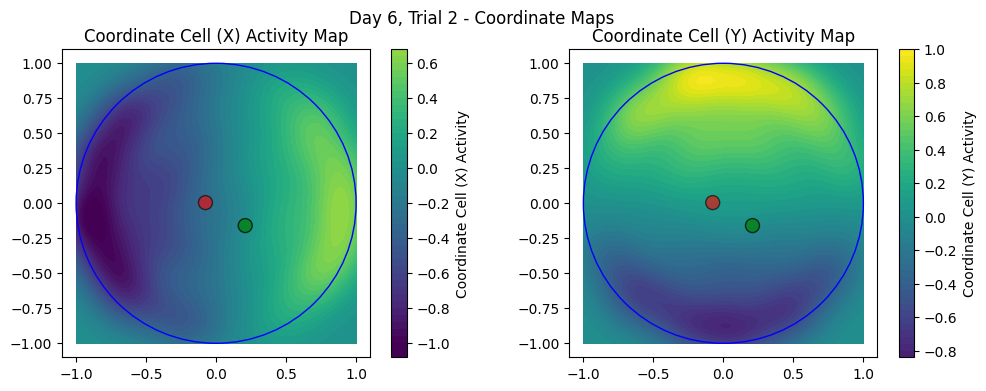

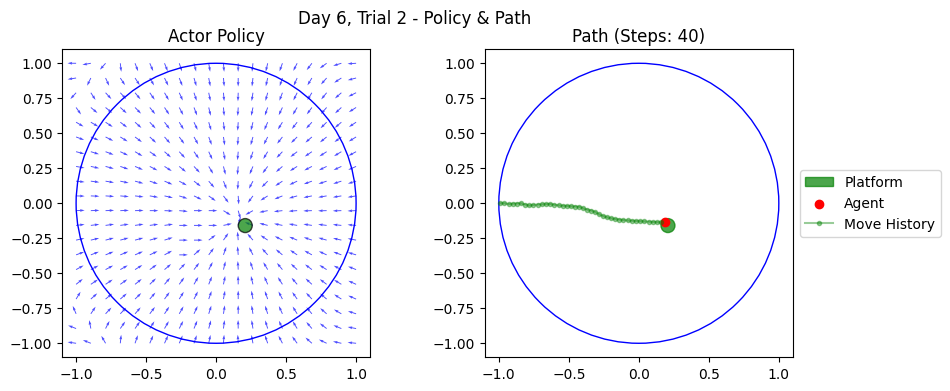

--- Starting Day 7 (Platform: [0.17129686 0.66360515]) ---
--- Starting Day 8 (Platform: [ 0.15787543 -0.77405326]) ---
--- Starting Day 9 (Platform: [ 0.31770228 -0.10716332]) ---


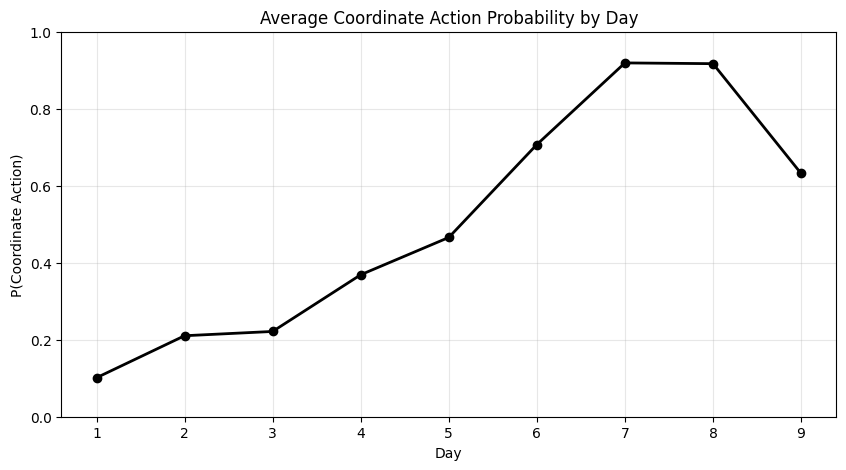

In [263]:
env = Environment()
c_agent = Coordinate_TD_Agent(env)
trials_per_day = 4
total_days = 9 

plot_targets = [(2, 2), (6, 2)] 

p_coordinate_actions = []

for day in range(1, total_days + 1):
    # Start of Day: Move platform if DMP
    # (paper uses DMP in figure 6)
    env.reset("DMP")
    
    print(f"--- Starting Day {day} (Platform: {env.platform_pos}) ---")
    
    for trial in range(1, trials_per_day + 1):
        #print(f"Day {day}, Trial {trial}:")
        if (day, trial) in plot_targets:
            print(f">>> Plotting Day {day}, Trial {trial}")
            
            # Coordinate Cell Activities (X and Y)
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f"Day {day}, Trial {trial} - Coordinate Maps")
            plt.sca(axes[0])
            c_agent.coordinates.display_cell_activity("x", plt_show=False, show_perceived_target=True)
            plt.sca(axes[1])
            c_agent.coordinates.display_cell_activity("y", plt_show=False, show_perceived_target=True)
            plt.show()
            
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            fig.suptitle(f"Day {day}, Trial {trial} - Policy & Path")
            
            # Actor Policy
            plt.sca(axes[0])
            c_agent.display_actor_policy(plt_show=False, title="Actor Policy")
            
            step_count, path_len, _, _, p_coord = c_agent.run_trial("RMW")
            
            # Path Plotting
            plt.sca(axes[1])
            env.display(plt_show=False, title=f"Path (Steps: {step_count})")
            plt.show()
            
        else:
            step_count, path_len, _, _, p_coord = c_agent.run_trial("RMW")
        
        p_coordinate_actions.append(p_coord)

p_coordinate_actions = np.array(p_coordinate_actions)
daily_means = p_coordinate_actions.reshape(-1, trials_per_day).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.title(f"Average Coordinate Action Probability by Day")
plt.plot(range(1, total_days + 1), daily_means, marker='o', linewidth=2, color='black')
plt.xlabel("Day")
plt.ylabel("P(Coordinate Action)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

---
# Figure 8
### 100 Simulations ("quick" version for testing, enough to see trends)
---

## Figure 8.a

Experiment Time: 65.02 seconds


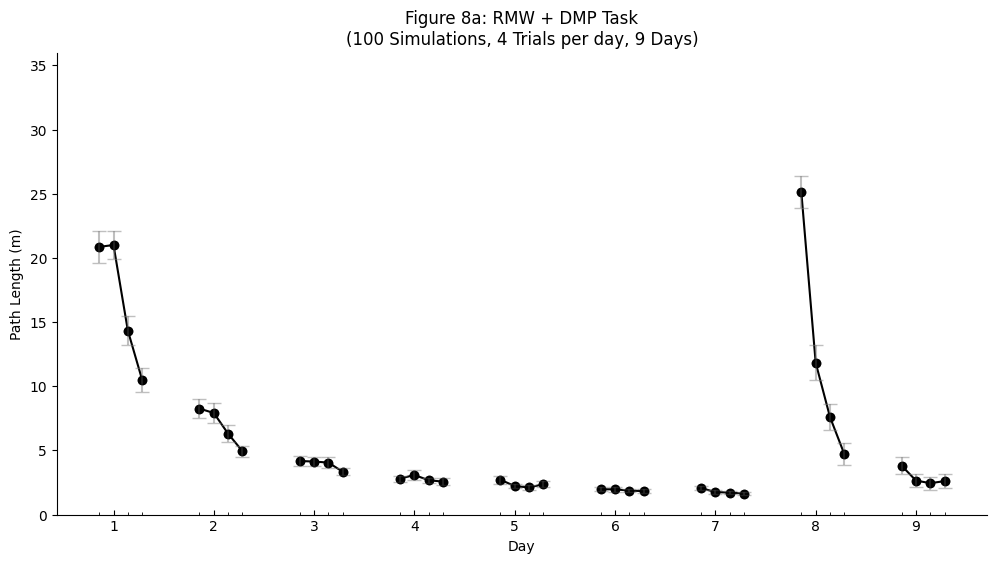

In [257]:
env = Environment()
agent = Coordinate_TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 100

start_time = time.time()
results_8a = agent.run_figure8(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day, verbose=False)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure8(results_8a, title=f"Figure 8a: RMW + DMP Task\n({simulation_count} Simulations, {trials_per_day} Trials per day, {len(trials_by_day)} Days)")

## Figure 8.b

Experiment Time: 196.77 seconds


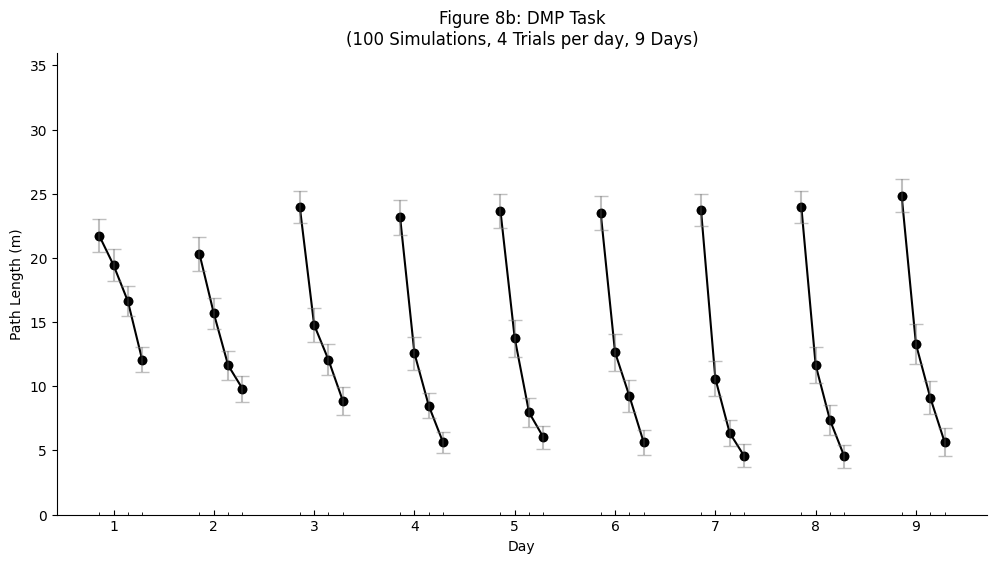

In [249]:
env = Environment()
agent = Coordinate_TD_Agent(env)

trials_by_day = 9 * ["DMP"]
trials_per_day = 4
simulation_count = 100

start_time = time.time()
results_8b = agent.run_figure8(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day, verbose=False)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure8(results_8b, title=f"Figure 8b: DMP Task\n({simulation_count} Simulations, {trials_per_day} Trials per day, {len(trials_by_day)} Days)")

---
# Figure 8
### 1000 Simulations (Like in the paper)
---

## Figure 8a

Experiment Time: 651.77 seconds


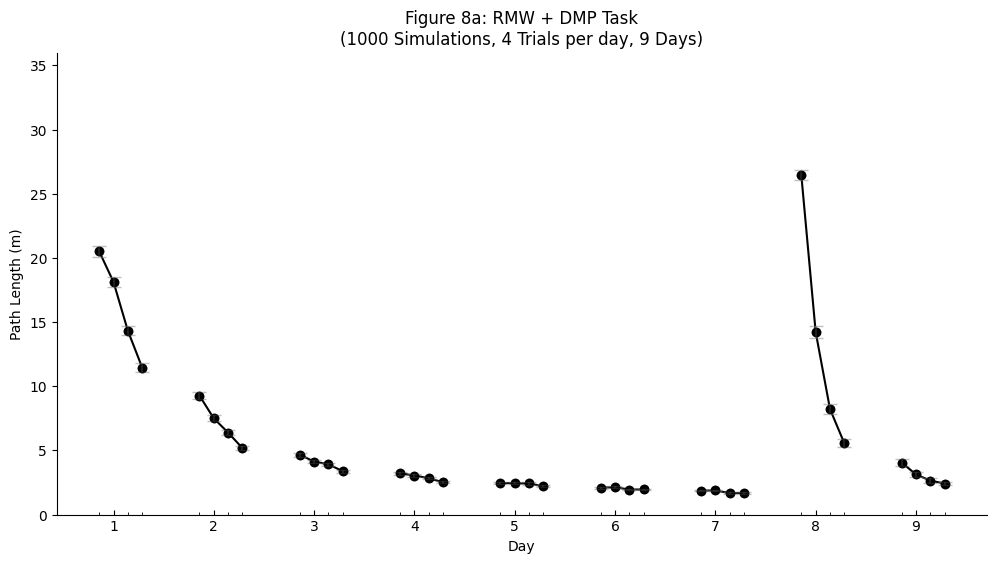

In [264]:
env = Environment()
agent = Coordinate_TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 1000

start_time = time.time()
results_8a = agent.run_figure8(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure8(results_8a, title=f"Figure 8a: RMW + DMP Task\n({simulation_count} Simulations, {trials_per_day} Trials per day, {len(trials_by_day)} Days)")

## Figure 8b

Experiment Time: 16.13 seconds


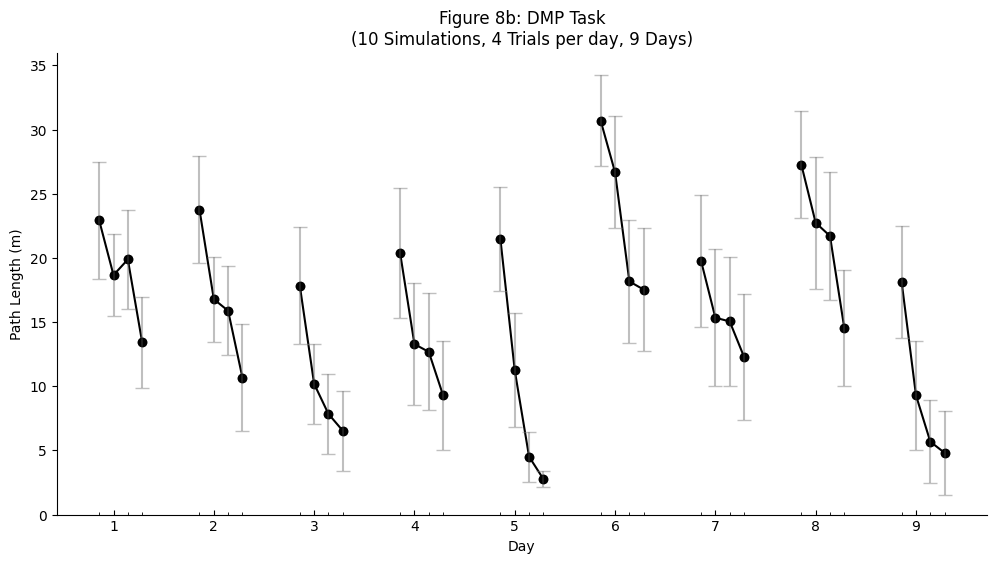

In [ ]:
env = Environment()
agent = Coordinate_TD_Agent(env)

trials_by_day = 9 * ["DMP"]
trials_per_day = 4
simulation_count = 1000

start_time = time.time()
results_8b = agent.run_figure8(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure8(results_8b, title=f"Figure 8b: DMP Task\n({simulation_count} Simulations, {trials_per_day} Trials per day, {len(trials_by_day)} Days)")